In [17]:
import numpy as np
import torch
import os
import numpy as np
import sigpy.mri as spmri
import sigpy as sp
import matplotlib.pyplot as plt

# --- Optional CuPy import + capability check ---
try:
    import cupy as cp
    _cupy_ok = True
    try:
        _gpu_count = cp.cuda.runtime.getDeviceCount()
        _cupy_ok = _gpu_count > 0
    except Exception:
        _cupy_ok = False
except Exception:
    cp = None
    _cupy_ok = False

from utils.show_slice import show_slice, show_kspace_slice, header_info
from utils.fftnc import fftnc, ifftnc # normalised fft and ifft for n dimensions
from utils.espiritmaps import calc_espirit_maps, to_espirit_dims, from_espirit_dims

# Set device for SigPy and PyTorch 
sp_device = sp.Device(0) if _cupy_ok else sp.Device(-1)
device = torch.device("cuda:0" if _cupy_ok and torch.cuda.is_available() else "cpu")

# This a a slice from fastMRI dataset saved as a numpy array to test this pipeline
kspace = np.load("data/kspace.npz")['arr_0']
kspace = torch.from_numpy(kspace).to(device)

nCha, nX, nY, nSlices = kspace.shape
image_shape = nX, nY, nSlices, nCha

Protocol: AX T1_FBB

Scanner: SIEMENS Skyra 2.8936 T

Coils: 20

Matrix: 640 x 320

FOV: 440 mm x 220 mm

TR: 250 ms

TE: 3.4 ms

### Changing Parameters

In [ ]:
max_motion = 4 # in cm
seed = 3

max_motion = max_motion * 3/2  # ~~ in pixels

EspiritCalib: 100%|██████████| 100/100 [00:00<00:00, 141.85it/s]


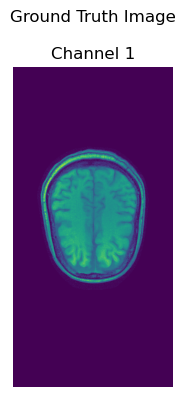

In [19]:
espirit_maps = from_espirit_dims(calc_espirit_maps(kspace, acs = 48, kernel_width=12, sp_device=sp_device)) # width, height, slices, coils
kspace_img = from_espirit_dims(kspace)  # width, height, slices, coils
img_cplx = ifftnc(kspace_img, dims=(-4, -3, -2))
p_true = torch.sum(img_cplx*espirit_maps.conj(), dim=-1).to(device)  # Ground truth image

show_slice(p_true, max_images=1, headline="Ground Truth Image")

EspiritCalib: 100%|██████████| 100/100 [00:00<00:00, 198.18it/s]


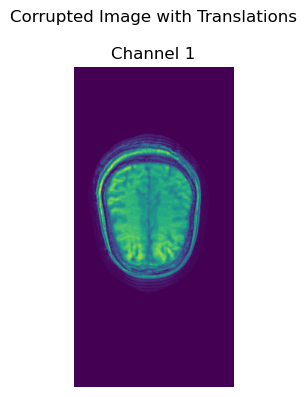

In [20]:
from utils.createArtifacts import randomTranslation_3D

# Create corrupted image with random translations
img_corrupted, t_n, masks = randomTranslation_3D(img_cplx, is_2D=True, sigma = max_motion, seed = seed)
kspace_corrupted = fftnc(img_corrupted, dims=(-4, -3, -2)).to(device)

# Calculate ESPIRiT maps from corrupted image
espirit_maps_corrupted = calc_espirit_maps(to_espirit_dims(kspace_corrupted), acs = 48, kernel_width=6, sp_device = sp_device)
espirit_maps_corrupted = from_espirit_dims(espirit_maps_corrupted)

# Show corrupted image
p_corrupted = torch.sum(img_corrupted*espirit_maps_corrupted.conj(), dim=-1)
show_slice(p_corrupted, max_images=1, headline="Corrupted Image with Translations")

In [21]:
from utils.EHE import EH, EHE

iterations = 5  # Number of motion states for reconstruction
b = EH(kspace_corrupted, t_n = t_n, iterations = iterations, masks= masks, sigmas = espirit_maps_corrupted, image_shape = image_shape)
EHEp = EHE(p_true, t_n = t_n, iterations = iterations, masks= masks, sigmas = espirit_maps_corrupted, image_shape = image_shape)

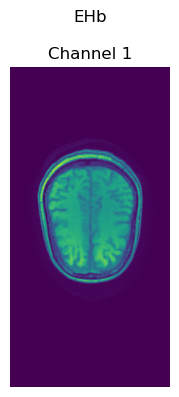

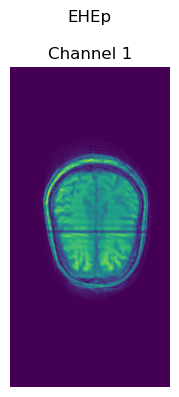

In [22]:
show_slice(b.view(640,320,1), max_images=1, headline="EHb")
show_slice(EHEp.view(640,320,1), max_images=1, headline="EHEp")

In [23]:
# the regularization term
lambda_= 1e-3

lambda_scaled = lambda_ * torch.norm(b, p=2)

x0 = torch.zeros_like(b, device=device, dtype=torch.complex64)

eye = torch.ones_like(b, device=device, dtype=torch.complex64)
A = EHE(eye, t_n=t_n, iterations=iterations, masks=masks, sigmas=espirit_maps_corrupted, image_shape=image_shape) + eye * lambda_scaled

Breakdown at iteration 52.


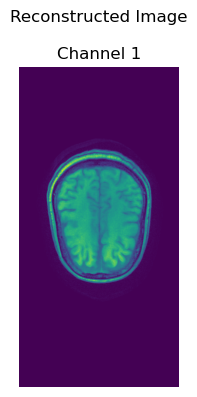

In [24]:
from utils.conjugate_gradient import cg

with torch.no_grad():
    x_rec, info = cg(A, b, x0, max_iter=300, tol=1e-4, regularisation=lambda_scaled)

show_slice(x_rec.view(640,320,1), max_images=1, headline="Reconstructed Image")